In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -r "/content/drive/MyDrive/GEO_AI_Cropland_Mapping_Challenge/requirements.txt"

In [ ]:
import pandas as pd
import numpy as np
import random
import time, os, json, datetime as dt,time
from typing import Optional, List, Dict, Any,Tuple
from joblib import load

#visuals
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

#sklearn
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

#models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

#saving models
from joblib import dump

import warnings
warnings.filterwarnings("ignore")

In [ ]:
start = time.time()

In [ ]:
#reproducability
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/GEO_AI_Cropland_Mapping_Challenge/"

In [ ]:
df_train = pd.read_csv(DATA_PATH + "/Modelling_data/train_data.csv")
df_test = pd.read_csv(DATA_PATH + "/Modelling_data/test_data.csv")

In [ ]:
df_train.head()

,ID,region,VH_m1,VH_m4,VH_m5,VH_m6,VH_m7,VH_m8,VH_m9,VH_m10,...,B11_summer_amp,TVI_summer_mean,TVI_summer_max,TVI_summer_amp,VV_summer_amp,VH_summer_amp,RATIO_summer_mean,RATIO_summer_max,RATIO_summer_amp,Cropland
0,1,0,0.633130,1.084777,1.484426,1.407917,1.299932,1.214758,0.635802,1.090500,...,0.730315,60.000000,60.000000,0.000000,0.206655,0.085174,1.115989,1.180200,0.128421,0
1,1,1,1.021577,-0.369721,-1.761019,-2.311180,-2.110178,-2.027716,-1.945255,-1.862793,...,1.923228,13.518482,43.770026,53.770026,0.382668,0.082461,2.397795,2.949165,1.102741,0
2,10,0,3.274543,3.381578,3.527864,3.336102,3.474119,3.690296,3.561098,3.783919,...,0.592520,14.832199,56.877694,66.877694,0.069927,0.216177,0.729204,0.756389,0.054371,0
3,10,1,-0.153589,-0.153589,-1.114856,0.016049,-1.801946,-2.130420,-2.157513,-1.253651,...,0.415354,25.000000,60.000000,70.000000,0.249331,0.328475,1.656241,1.691742,0.071001,0
4,100,0,0.201310,0.821459,1.122925,0.858862,1.570204,1.364598,1.133099,0.544026,...,4.405512,7.500000,60.000000,70.000000,0.131508,0.205605,1.722243,1.734492,0.024497,0


In [ ]:
df_test.head()

,ID,region,VH_m1,VH_m2,VH_m3,VH_m4,VH_m5,VH_m6,VH_m7,VH_m8,...,TVI_summer_amp,VV_summer_mean,VV_summer_max,VV_summer_amp,VH_summer_mean,VH_summer_max,VH_summer_amp,RATIO_summer_mean,RATIO_summer_max,RATIO_summer_amp
0,ID_ABQOQT,0,-0.386597,-0.183287,0.187786,0.647320,0.778800,0.881496,0.536325,-0.041356,...,58.023236,0.267288,0.447205,0.359834,0.247485,0.536325,0.577682,0.362972,1.199282,1.672621
1,ID_ADDROF,0,0.345713,0.511547,0.564527,0.387538,0.727787,0.601722,0.622308,0.699188,...,30.046859,1.092650,1.194624,0.203948,0.660748,0.699188,0.076880,0.613346,0.705768,0.184844
2,ID_AFIWZH,0,0.788790,0.893858,1.133444,1.167485,1.277445,1.205645,1.237062,1.204274,...,0.000000,1.753007,1.808599,0.111185,1.220668,1.237062,0.032789,0.696732,0.709475,0.025486
3,ID_AFQOFP,0,-1.379005,-1.567074,-1.075241,-0.220665,0.361806,-0.302459,-0.665902,-0.905316,...,70.000000,-1.166923,-1.025754,0.282338,-0.785609,-0.665902,0.239414,0.670636,0.692089,0.042907
4,ID_AHRONV,1,0.709818,0.709818,0.709818,-1.119731,-1.586254,-1.622434,-1.354346,-1.737666,...,59.765103,-1.853504,-1.360648,0.985713,-1.546006,-1.354346,0.383321,0.867974,0.995368,0.254789


In [ ]:
df_train.groupby(['region','Cropland'])['Cropland'].count()

region  Cropland
0       0           393
        1           107
1       0           310
        1           190
Name: Cropland, dtype: int64

In [ ]:
target = 'Cropland'
columns = df_train.columns.difference(['ID', 'region', 'folds',target])
columns

Index(['ACI_m10', 'ACI_m11', 'ACI_m12', 'ACI_m4', 'ACI_m5', 'ACI_m6', 'ACI_m7',
       'ACI_m8', 'ACI_m9', 'ARVI_m1',
       ...
       'vh_vv_ratio_m11', 'vh_vv_ratio_m12', 'vh_vv_ratio_m2',
       'vh_vv_ratio_m3', 'vh_vv_ratio_m4', 'vh_vv_ratio_m5', 'vh_vv_ratio_m6',
       'vh_vv_ratio_m7', 'vh_vv_ratio_m8', 'vh_vv_ratio_m9'],
      dtype='object', length=512)

## MODELLING

In [ ]:
exp_code = str(round(time.time() * 1000))

In [ ]:
def _safe_splits(y, n_splits):
  """
  ensures there enough points in the target class in order to split during cross validation
  """
  c = y.value_counts()
  return max(2, min(n_splits, int(c.min()) if len(c) else 2))

def _regionize_pipeline(base_pipe, use_sampler, sampler=None, sampler_step_name="sampler"):
  """
  Clone `base_pipe` and ensure it has a `sampler` step:
    - if use_sampler: set to sampler
    - else: set to 'passthrough'
  Works whether or not the original pipe already had a 'sampler' step.
  """
  sampler = sampler or RandomOverSampler(random_state=20, sampling_strategy="auto")
  pipe = clone(base_pipe)

  # Normalize to an imblearn Pipeline
  if not isinstance(pipe, ImbPipeline):
      pipe = ImbPipeline(pipe.steps)

  names = [n for n, _ in pipe.steps]
  if sampler_step_name in names:
      # toggle existing step
      pipe.set_params(**{sampler_step_name: (sampler if use_sampler else "passthrough")})
  else:
      # insert after 'imputer' if present, else at start
      insert_idx = names.index("imputer") + 1 if "imputer" in names else 0
      new_steps = pipe.steps[:insert_idx] + [(sampler_step_name, sampler if use_sampler else "passthrough")] + pipe.steps[insert_idx:]
      pipe = ImbPipeline(new_steps)
  return pipe

In [ ]:
def overall_oof_accuracy_by_region(models, df_train, feature_cols,
                                   target_col="Cropland", region_col="region",
                                   n_splits=5, random_state=42,
                                   sampler_regions=None, sampler=None,
                                   save_dir=None):

    """
    Selects the best-performing model **per region** via cross-validation accuracy,
    generates out-of-fold (OOF) predictions for that chosen model, computes
    per-region and overall OOF accuracy, and (optionally) fits & saves final
    region-specific pipelines to disk with a metadata manifest
    """
    sampler_regions = set(sampler_regions or [])
    regions = sorted(df_train[region_col].unique())
    per_region = {}
    chosen_models = {}
    saved_paths = {}
    meta = {}
    y_all, yhat_all = [], []

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    for r in regions:
        tr = df_train[df_train[region_col] == r]
        X, y = tr[feature_cols], tr[target_col].astype(int)

        if y.nunique() < 2 or len(y) < 2:
            print(f"[warn] Region {r}: single class or too few samples; skipping.")
            continue

        # pick best model by CV accuracy
        splits = _safe_splits(y, n_splits)
        skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=random_state)

        best_name, best_cv = None, -np.inf
        for name, base in models.items():
            pipe = _regionize_pipeline(base, use_sampler=(r in sampler_regions), sampler=sampler)
            try:
                cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring="accuracy")
                mean_acc = cv_scores.mean()
            except Exception:
                continue
            if mean_acc > best_cv:
                best_cv, best_name = mean_acc, name

        if best_name is None:
            print(f"[warn] Region {r}: no valid model.")
            continue

        # OOF predictions with chosen model
        skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=random_state)
        best_pipe = _regionize_pipeline(models[best_name], use_sampler=(r in sampler_regions), sampler=sampler)
        yhat_oof = cross_val_predict(best_pipe, X, y, cv=skf, method="predict")

        acc = accuracy_score(y, yhat_oof)
        per_region[r] = {
            "best_model": best_name,
            "cv_mean": float(best_cv),
            "oof_accuracy": float(acc),
            "n_samples": int(len(y))
        }
        chosen_models[r] = best_name
        y_all.append(y.values)
        yhat_all.append(yhat_oof)

        # ---- Fit on full region data & save to disk ----
        if save_dir:
            final_pipe = _regionize_pipeline(models[best_name], use_sampler=(r in sampler_regions), sampler=sampler)
            final_pipe.fit(X, y)
            path = os.path.join(save_dir, f"region_{r}__{best_name}.pkl")
            dump(final_pipe, path, compress=3)
            saved_paths[r] = path

            # Metadata entry
            meta[str(r)] = {
                "model_name": best_name,
                "pipeline_steps": [n for n, _ in final_pipe.steps],
                "cv_mean": float(best_cv),
                "oof_accuracy": float(acc),
                "n_samples": int(len(y)),
                "feature_cols": list(feature_cols),
                "saved_at": dt.datetime.now().isoformat(timespec="seconds"),
                "path": path
            }

    overall_acc = float(accuracy_score(np.concatenate(y_all), np.concatenate(yhat_all))) if y_all else None

    # Write metadata.json
    if save_dir:
        with open(os.path.join(save_dir, "metadata.json"), "w") as f:
            json.dump(meta, f, indent=2)

    return overall_acc, per_region, chosen_models, saved_paths


## GENERATE SUBMISSION FILE

In [ ]:
def generate_submission_file(df_test, feature_cols, models_dir,
                             out_path="submission.csv",
                             id_col="ID", region_col="region",
                             target_col="Cropland"):
    """
    Use the saved best models from training to generate predictions.

    df_test     : test DataFrame
    feature_cols: list of features
    models_dir  : folder with metadata.json and .pkl models
    out_path    : path for CSV submission
    """

    # 1. Load metadata
    meta_path = os.path.join(models_dir, "metadata.json")
    with open(meta_path, "r") as f:
        meta = json.load(f)

    # 2. Prepare empty list for results
    preds = []

    # 3. Loop over regions
    for r, info in meta.items():
        # load the model for this region
        model_path = info["path"]
        pipe = load(model_path)

        # subset test rows for this region
        test_r = df_test[df_test[region_col].astype(str) == r]
        if test_r.empty:
            continue

        # predict
        Xr = test_r[feature_cols]
        yr_pred = pipe.predict(Xr)

        # collect with IDs
        part = pd.DataFrame({
            id_col: test_r[id_col].values,
            target_col: yr_pred
        })
        preds.append(part)

    # 4. Combine all regions
    submission = pd.concat(preds, axis=0).sort_values(id_col)

    # 5. Save CSV
    submission.to_csv(out_path, index=False)
    print(f"Saved submission to {out_path}")
    return submission

## FEATURE IMPORTANCE

In [ ]:
def load_models(out_dir):
    """Load saved models and metadata."""
    with open(os.path.join(out_dir, "metadata.json")) as f:
        meta = json.load(f)
    models = {r: load(info["path"]) for r, info in meta.items()}
    return models, meta

def get_feature_importance(pipe, feature_cols, X=None, y=None):
    """
    Return a DataFrame of feature importance.
    Uses model's own feature_importances_ or coef_ if available,
    otherwise falls back to permutation importance (needs X,y).
    """
    # If there was feature selection in the pipeline, apply its mask
    if hasattr(pipe, "named_steps"):
        for step in pipe.named_steps.values():
            if hasattr(step, "get_support"):
                mask = step.get_support()
                feature_cols = [c for c, keep in zip(feature_cols, mask) if keep]

    est = pipe.steps[-1][1] if hasattr(pipe, "steps") else pipe

    if hasattr(est, "feature_importances_"):
        imp = est.feature_importances_
    elif hasattr(est, "coef_"):
        coef = np.array(est.coef_)
        imp = np.abs(coef).mean(axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        if X is None or y is None:
            raise ValueError("Need X and y for permutation importance.")
        X = X[feature_cols]
        imp = permutation_importance(pipe, X, y, n_repeats=10, random_state=42).importances_mean

    return pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values(
        "importance", ascending=False
    )


In [ ]:
def plot_feature_importance(fi_dict, top_n=10):
    n_regions = len(fi_dict)

    fig, axes = plt.subplots(1, n_regions, figsize=(4*n_regions, 0.3*top_n), sharey=False)

    if n_regions == 1:
        axes = [axes]  # make iterable if only one region

    for ax, (r, df) in zip(axes, fi_dict.items()):
        top = df.head(top_n).iloc[::-1]
        ax.barh(top["feature"], top["importance"])
        ax.set_title(f"Region {r}")
        ax.set_xlabel("Importance")
        ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.show()


## NO TUNING

In [ ]:
#Choose which region(s) should use oversampling
sampler_regions = {1}  # or {"Orenburg"}
sampler_choice = RandomOverSampler(random_state=20, sampling_strategy="auto")

prep_steps = [
    ("imputer", SimpleImputer(strategy="mean")),
    ("sampler", sampler_choice),
    ("scaler", StandardScaler()),                      # ok to keep even for tree models (harmless)
    ("feature_selection", SelectKBest(f_classif, k=60))
]

models = {
    "RandomForest": Pipeline(prep_steps + [
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "LogisticRegression": Pipeline(prep_steps + [
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "LGBM": Pipeline(prep_steps + [
        ("model", LGBMClassifier(random_state=42, n_estimators=2000, verbose=-1))
    ]),
    "XGBoost": Pipeline(prep_steps + [
        ("model", XGBClassifier(random_state=42))
    ]),
    # "Catboost": Pipeline(prep_steps + [
    #     ("model", CatBoostClassifier(random_state=42, verbose=0,early_stopping_rounds=50))
    # ]),
}

feature_cols = [c for c in df_train.columns if c not in ['ID', 'region', 'folds', 'Cropland']]

In [ ]:
OUTPUT_DIR = DATA_PATH +  "untuned_best_models/" + exp_code

overall_oof, per_region_oof, best_models,saved_path = overall_oof_accuracy_by_region(
    models=models,
    df_train=df_train,
    feature_cols=feature_cols,
    target_col="Cropland",
    region_col="region",
    n_splits=5,
    random_state=42,
    sampler_regions=sampler_regions,   # e.g., only oversample region 1; use {"Orenburg"} if names
    sampler=sampler_choice, # pass a configured RandomOverSampler
    save_dir=OUTPUT_DIR
)

print("Overall OOF accuracy:", overall_oof)
print(per_region_oof)      # shows each region’s best model, CV mean, and OOF accuracy
print(best_models)             # best model name per region



Overall OOF accuracy: 0.869
{np.int64(0): {'best_model': 'XGBoost', 'cv_mean': 0.9219999999999999, 'oof_accuracy': 0.922, 'n_samples': 500}, np.int64(1): {'best_model': 'RandomForest', 'cv_mean': 0.8160000000000001, 'oof_accuracy': 0.816, 'n_samples': 500}}
{np.int64(0): 'XGBoost', np.int64(1): 'RandomForest'}


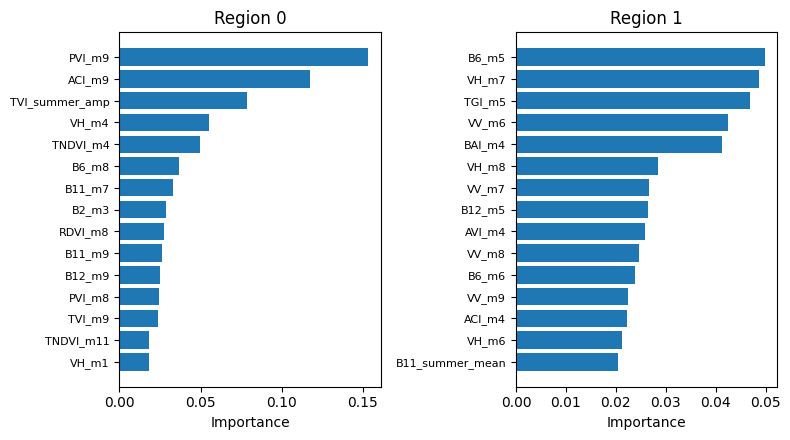

In [ ]:
#Feature importance
untuned_models, meta = load_models(OUTPUT_DIR)

fi_dict = {}
for r, pipe in untuned_models.items():
    cols = meta[r]["feature_cols"]
    tr = df_train[df_train["region"] == int(r)]
    X, y = tr[cols], tr["Cropland"].astype(int)
    fi_dict[r] = get_feature_importance(pipe, cols, X=X, y=y)

plot_feature_importance(fi_dict, top_n=15)

In [ ]:
submission_untuned = generate_submission_file(
    df_test=df_test,
    feature_cols=feature_cols,
    models_dir=OUTPUT_DIR,
    out_path=OUTPUT_DIR + "/" + f'untuned_oof-acc_{overall_oof}.csv',
    id_col="ID",
    region_col="region",
    target_col="Cropland"
)

Saved submission to /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/untuned_best_models/1759309875397/untuned_oof-acc_0.869.csv


In [ ]:
submission_untuned.head()

,ID,Cropland
0,ID_ABQOQT,0
1,ID_ADDROF,0
2,ID_AFIWZH,0
3,ID_AFQOFP,0
0,ID_AHRONV,0


In [ ]:
submission_untuned['Cropland'].value_counts()

,count
Cropland,
0,396
1,204


## TUNED - RANDOM SEARCH

In [ ]:
def _ensure_imblearn_pipe(pipe):
    if isinstance(pipe, ImbPipeline):
        return pipe
    return ImbPipeline(pipe.steps)

def _insert_sampler_before_final(pipe, sampler_step_name, sampler):
    names = [n for n, _ in pipe.steps]
    if sampler_step_name in names:
        pipe.set_params(**{sampler_step_name: sampler})
        return pipe
    insert_idx = len(pipe.steps) - 1
    new_steps = pipe.steps[:insert_idx] + [(sampler_step_name, sampler)] + pipe.steps[insert_idx:]
    return ImbPipeline(new_steps)

In [ ]:
def nested_oof_and_submission_by_region(
    models,                 # dict[name] -> Pipeline
    param_spaces,           # dict[name] -> distributions
    df_train, df_test, feature_cols,
    target_col="Cropland", region_col="region",
    sampler_regions=None, sampler=None, sampler_step_name="sampler",
    outer_splits=5, inner_splits=3,
    n_iter=20, scoring="accuracy", random_state=42, n_jobs=1,
    proba=False,
    save_dir=None
):
    """
    uses a nested cross validation strategy and hypeparameter to search for the best model.
    Saves (if save_dir given):
      save_dir/
        region_<r>__<best_name>.pkl
        metadata.json  # with per-region entries:
                       # meta[str(r)] = {
                       #   "model_name","pipeline_steps","cv_mean","oof_accuracy",
                       #   "n_samples","feature_cols","saved_at","path"
                       # }
    Returns:
      overall_oof_acc, per_region, winners, submission, final_estimators, saved_paths, meta_path
    """
    sampler_regions = set(sampler_regions or [])
    regions = sorted(df_train[region_col].unique())

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    per_region = {}
    winners = {}
    final_estimators = {}
    saved_paths = {}
    meta = {}

    y_all, yhat_all = [], []
    submission_parts = []

    for r in regions:
        tr = df_train[df_train[region_col] == r]
        te = df_test[df_test[region_col] == r]
        if tr.empty or te.empty:
            print(f"[warn] Region {r}: missing train or test rows; skipping.")
            continue

        X, y = tr[feature_cols], tr[target_col].astype(int)
        X_test, ids = te[feature_cols], te["ID"].values

        if y.nunique() < 2 or len(y) < 2:
            print(f"[warn] Region {r}: single-class or too few samples; skipping.")
            continue

        # ----- OUTER CV (model selection) -----
        n_outer = _safe_splits(y, outer_splits)
        outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=random_state)

        model_outer_scores, model_oof_preds, model_oof_true = {}, {}, {}

        for name, base_pipe in models.items():
            fold_accs, outer_fold_true, outer_fold_preds = [], [], []
            model_valid = True

            for tr_idx, va_idx in outer_cv.split(X, y):
                X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
                X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

                n_inner = _safe_splits(y_tr, inner_splits)
                inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=random_state)

                pipe = _regionize_pipeline(
                    base_pipe, use_sampler=(r in sampler_regions),
                    sampler=sampler, sampler_step_name=sampler_step_name
                )

                space = param_spaces.get(name, {})
                n_iter_this = n_iter if space else 1  # safe empty space

                try:
                    tuner = RandomizedSearchCV(
                        estimator=pipe,
                        param_distributions=space,
                        n_iter=n_iter_this,
                        scoring=scoring,
                        cv=inner_cv,
                        refit=True,
                        random_state=random_state,
                        n_jobs=n_jobs,
                        verbose=0
                    )
                    tuner.fit(X_tr, y_tr)
                    est = tuner.best_estimator_
                    y_hat = est.predict(X_va)
                    fold_accs.append(accuracy_score(y_va, y_hat))
                    outer_fold_preds.append(y_hat)
                    outer_fold_true.append(y_va.values)
                except Exception as e:
                    print(f"[skip] {name} @ region {r} outer-fold: {e}")
                    model_valid = False
                    break

            if model_valid and fold_accs:
                model_outer_scores[name] = (float(np.mean(fold_accs)), float(np.std(fold_accs)))
                model_oof_preds[name] = np.concatenate(outer_fold_preds)
                model_oof_true[name]  = np.concatenate(outer_fold_true)

        if not model_outer_scores:
            print(f"[warn] Region {r}: no model succeeded in nested CV; skipping.")
            continue

        # pick best by mean outer-fold accuracy
        best_name = max(model_outer_scores, key=lambda k: model_outer_scores[k][0])
        best_mean, best_std = model_outer_scores[best_name]
        oof_true = model_oof_true[best_name]
        oof_pred = model_oof_preds[best_name]
        oof_acc = float(accuracy_score(oof_true, oof_pred))

        per_region[r] = {
            "best_model": best_name,
            "outer_mean": float(best_mean),
            "outer_std": float(best_std),
            "oof_accuracy": oof_acc,
            "n_outer": int(n_outer),
            "sampler_on": bool(r in sampler_regions),
            "oof_count": int(len(oof_true)),
        }
        winners[r] = best_name

        y_all.append(oof_true)
        yhat_all.append(oof_pred)

        # ----- FINAL REFIT ON FULL REGION + SAVE -----
        try:
            n_inner_full = _safe_splits(y, inner_splits)
            inner_full_cv = StratifiedKFold(n_splits=n_inner_full, shuffle=True, random_state=random_state)

            final_pipe = _regionize_pipeline(
                models[best_name], use_sampler=(r in sampler_regions),
                sampler=sampler, sampler_step_name=sampler_step_name
            )
            space = param_spaces.get(best_name, {})
            n_iter_this = n_iter if space else 1

            final_tuner = RandomizedSearchCV(
                estimator=final_pipe,
                param_distributions=space,
                n_iter=n_iter_this,
                scoring=scoring,
                cv=inner_full_cv,
                refit=True,
                random_state=random_state,
                n_jobs=n_jobs,
                verbose=0
            )
            final_tuner.fit(X, y)
            best_est_full = final_tuner.best_estimator_
            final_estimators[r] = best_est_full

            # predictions for test
            if proba:
                if hasattr(best_est_full, "predict_proba"):
                    test_pred = best_est_full.predict_proba(X_test)[:, 1]
                elif hasattr(best_est_full, "decision_function"):
                    test_pred = best_est_full.decision_function(X_test)
                else:
                    test_pred = best_est_full.predict(X_test)
                pred_col = f"{target_col}_proba"
            else:
                test_pred = best_est_full.predict(X_test)
                pred_col = target_col

            submission_parts.append(pd.DataFrame({"ID": ids, pred_col: test_pred, region_col: r}))

            # ---- save in your untuned format ----
            if save_dir:
                path = os.path.join(save_dir, f"region_{r}__{best_name}.pkl")
                dump(best_est_full, path, compress=3)
                saved_paths[r] = path

                meta[str(r)] = {
                    "model_name": best_name,
                    "pipeline_steps": [n for n, _ in getattr(best_est_full, "steps", [])],
                    "cv_mean": float(best_mean),
                    "oof_accuracy": float(oof_acc),
                    "n_samples": int(len(y)),
                    "feature_cols": list(feature_cols),
                    "best_params": final_tuner.best_params_,
                    "saved_at": dt.datetime.now().isoformat(timespec="seconds"),
                    "path": path
                }

        except Exception as e:
            print(f"[warn] Region {r}: final refit failed: {e}")

    overall_oof_acc = float(accuracy_score(np.concatenate(y_all), np.concatenate(yhat_all))) if y_all else None
    submission = (pd.concat(submission_parts).sort_values("ID").reset_index(drop=True)
                  if submission_parts else pd.DataFrame())

    # write metadata.json (same location & shape as your untuned flow)
    meta_path = None
    if save_dir:
        meta_path = os.path.join(save_dir, "metadata.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

    return overall_oof_acc, per_region, winners, submission, final_estimators, saved_paths

In [ ]:
#define the hyperparameter tuning search space
param_spaces = {
    "RandomForest": {
        "model__n_estimators": [200, 400, 600, 800, 1000],
        "model__max_depth": [None,5, 6, 10, 12, 7],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "LogisticRegression": {
        "model__C": np.logspace(-3, 3, 10),
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "LGBM": {
        "model__n_estimators": [300, 500, 800,1000,1500,2000],
        "model__num_leaves": [31, 63, 127],
        "model__learning_rate": [0.05,0.01, 0.1, 0.2],
        "model__min_child_samples": [10, 20, 50],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0]
    },
    "XGBoost": {
        "model__n_estimators": [300, 500, 800,150,1500],
        "model__max_depth": [None,3, 5, 7, 9],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0]
    },
}

In [ ]:
OUTPUT_DIR = DATA_PATH +  "tuned_best_models/" + exp_code
overall_oof_tuned, per_region_oof_tuned, best_models_tuned,submission_tuned,final_estimators,saved_path_tuned = nested_oof_and_submission_by_region(
    models=models,
    param_spaces = param_spaces,
    df_train=df_train,
    df_test=df_test,
    feature_cols=feature_cols,
    target_col="Cropland",
    region_col="region",
    random_state=42,
    sampler_regions=sampler_regions,   # e.g., only oversample region 1; use {"Orenburg"} if names
    sampler=sampler_choice, # pass a configured RandomOverSampler
    save_dir=OUTPUT_DIR
)

print("Overall OOF accuracy:", overall_oof_tuned)
print(per_region_oof_tuned)      # shows each region’s best model, CV mean, and OOF accuracy
print(best_models_tuned)             # best model name per region



Overall OOF accuracy: 0.869
{np.int64(0): {'best_model': 'LGBM', 'outer_mean': 0.9280000000000002, 'outer_std': 0.026381811916545816, 'oof_accuracy': 0.928, 'n_outer': 5, 'sampler_on': False, 'oof_count': 500}, np.int64(1): {'best_model': 'RandomForest', 'outer_mean': 0.8100000000000002, 'outer_std': 0.03633180424916989, 'oof_accuracy': 0.81, 'n_outer': 5, 'sampler_on': True, 'oof_count': 500}}
{np.int64(0): 'LGBM', np.int64(1): 'RandomForest'}


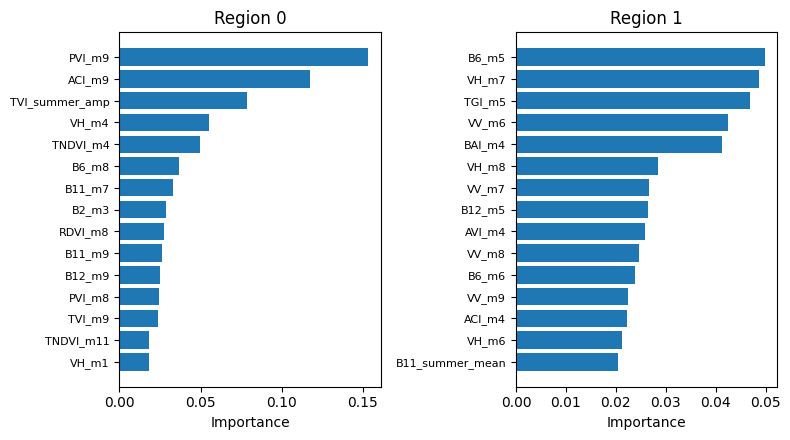

In [ ]:
#Feature importance
tuned_models, meta = load_models(OUTPUT_DIR)

fi_dict = {}
for r, pipe in untuned_models.items():
    cols = meta[r]["feature_cols"]
    tr = df_train[df_train["region"] == int(r)]
    X, y = tr[cols], tr["Cropland"].astype(int)
    fi_dict[r] = get_feature_importance(pipe, cols, X=X, y=y)

plot_feature_importance(fi_dict, top_n=15)

In [ ]:
submission_tuned = generate_submission_file(
    df_test=df_test,
    feature_cols=feature_cols,
    models_dir=OUTPUT_DIR,
    out_path=OUTPUT_DIR + "/" + f'tuned_oof-acc_{overall_oof_tuned}.csv',
    id_col="ID",
    region_col="region",
    target_col="Cropland"
)

Saved submission to /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/tuned_best_models/1759309875397/tuned_oof-acc_0.869.csv


In [ ]:
submission_tuned['Cropland'].value_counts()

,count
Cropland,
0,401
1,199


In [ ]:
end = time.time()

In [ ]:
print("Total time taken to run and generate best models : ",(end-start)/60,"minutes")


Total time taken to run and generate best models :  22.958226577440897 minutes
